## DAS-APL: Ejemplo de uso `das4whales`

In [3]:
import os
import sys
import numpy as np
import das4whales as dw
import scipy.signal as sp
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DAS_APL_NAS_SERVER_PATH = "Z:/DAS-APL"; sys.path.append(DAS_APL_NAS_SERVER_PATH)

from tools.yolo4das.annotation import annotate

In [4]:
# The dataset of this example is constituted of 60s time series along  66 km of cable

# url = 'http://piweb.ooirsn.uw.edu/das/data/Optasense/NorthCable/TransmitFiber/' \
#       'North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-03T15_06_51-0700/'\
#       'North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5'

# filepath, filename = dw.data_handle.dl_file(url)

In [ ]:
# Read HDF5 files and access metadata
# Get the acquisition parameters for the data folder and store them in a dictionary

filepath = 'Z:/DAS-APL/data/North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5'
metadata = dw.data_handle.get_acquisition_parameters(filepath, interrogator='optasense')

if True:
    fs = metadata['fs']                         # Sampling frequency [Hz]
    dx = metadata['dx']                         # Distance between channels [m]
    nx = metadata['nx']                         # Number of channels (channels)
    ns = metadata['ns']                         # Number of samples (time points)
    gauge_length = metadata['GL']               # Deformation integration length [m]
    scale_factor = metadata['scale_factor']     # Conversion to physical units (strain)

print(f'Sampling frequency: {metadata["fs"]} Hz')
print(f'Channel spacing: {metadata["dx"]} m')
print(f'Gauge length: {metadata["GL"]} m')
print(f'File duration: {metadata["ns"] / metadata["fs"]} s')
print(f'Cable max distance: {metadata["nx"] * metadata["dx"]/1e3:.1f} km')
print(f'Number of channels: {metadata["nx"]}')
print(f'Number of time samples: {metadata["ns"]}')

Sampling frequency: 200.0 Hz
Channel spacing: 2.0419046878814697 m
Gauge length: 51.0476188659668 m
File duration: 60.0 s
Cable max distance: 66.6 km
Number of channels: 32600
Number of time samples: 12000


In [ ]:
# List of values in meters corresponding to the starting ending and step wanted channels along the FO Cable
# selected_channels_m = [ChannelStart_m, ChannelStop_m, ChannelStep_m] in meters

CHANNEL_STRIDE = 1
selected_channels_m = [0, nx*dx, CHANNEL_STRIDE*dx] # (m)

# [ChannelStart, ChannelStop, ChannelStep]
selected_channels = [int(selected_channels_m // dx) for selected_channels_m in selected_channels_m] # idx

print('Begin channel: ', selected_channels[0])
print('End channel: ', selected_channels[1])
print('Step: ', selected_channels[2], '[', selected_channels[2] * dx, 'm ]')


Begin channel:  0
End channel:  15965
Step:  1 [ 2.0419047 m ]


In [13]:
# Load DAS data fro the example file: North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5
# load_das_data() allow to load only the desired channels

tr, time, dist, fileBeginTimeUTC = dw.data_handle.load_das_data(filepath, selected_channels, metadata)
print('Shape: ', tr.shape)

Shape:  (15965, 12000)


In [8]:
# Band-pass filtering (10-30 Hz, ord. 5) and high-pass filtering (5 Hz, ord. 2)
# Fs: 200 Hz

sos_bpfilter = dw.dsp.butterworth_filter([5, [15, 25], 'bp'], fs)
sos_hpfilter = dw.dsp.butterworth_filter([2, 5, 'hp'], fs)

# Apply only B-P filter
trf = sp.sosfiltfilt(sos_bpfilter, tr, axis=1)

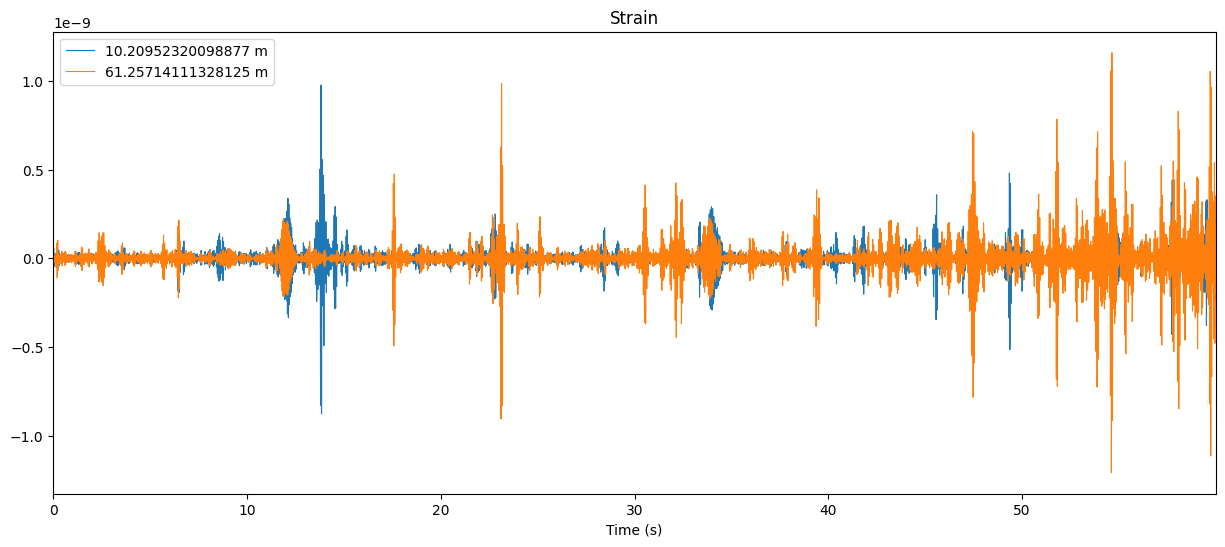

In [9]:
# Plot strain
points = [5, 30]
t = np.linspace(0, (ns - 1) / fs, num=nx)
data_to_plot = trf.copy()

%matplotlib inline
plt.figure(figsize=(15,6))
for point in points:
    plt.plot(time, data_to_plot[point, :], label=f'{point*dx} m', lw=0.8)
plt.title('Strain')
plt.xlabel('Time (s)')
plt.legend()
plt.xlim(np.min(t), np.max(t))
plt.show()

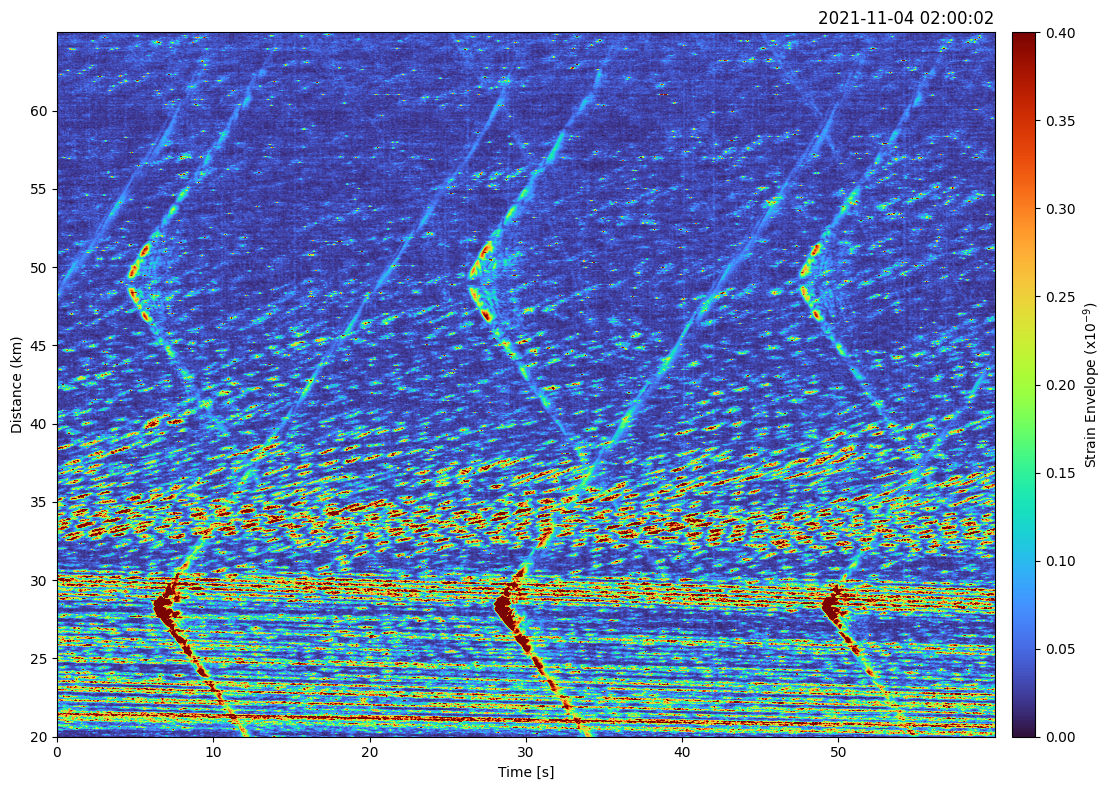

In [10]:
# TX plot (time x distance)

dw.plot.plot_tx(
    sp.hilbert(trf, axis=1), time, dist, fileBeginTimeUTC, 
    fig_size=(12, 8), v_min=0, v_max=0.4)

In [11]:
# Visualize and annotate the example data of the das4whales library using YOLO4DAS annotation tool
# We use the annotate() function which is agnostic to the data format

# import matplotlib; matplotlib.use("Qt5Agg")

# annotate(
#     tr=trf, 
#     dist_m=dist, time_s=time, 
#     fs_hz=fs, 
#     filename=filepath, 
#     vmin=0, vmax=0.4e-9,
#     start_datetime_utc=fileBeginTimeUTC,
#     save_dir=None,
#     save_directly=True,
#     annotations_output_format='csv',
#     data_output_format=None)

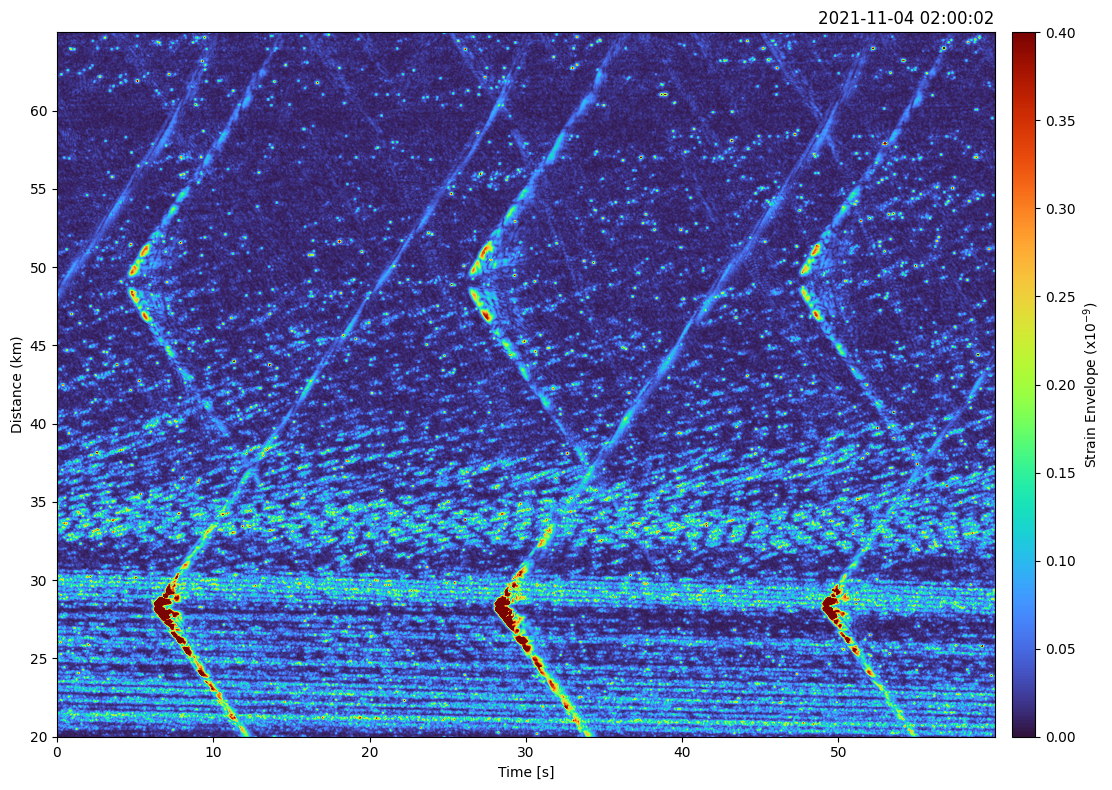

In [12]:
# Apply f-k (frequency-wavenumber) filtering and plot TX

fk_params_s = {
    'c_min': 1400.,     # m.s-1
    'c_max': 3500.,     # m.s-1
    'fmin': 10.,        # Hz
    'fmax': 30.         # Hz
}

fk_filter = dw.dsp.hybrid_ninf_gs_filter_design((tr.shape[0],tr.shape[1]), selected_channels, dx, fs, fk_params_s, display_filter=False)
trf_fk = dw.dsp.fk_filter_sparsefilt(trf, fk_filter, tapering=False)

dw.plot.plot_tx(sp.hilbert(trf_fk, axis=1), time, dist, fileBeginTimeUTC, fig_size=(12, 8), v_min=0, v_max=0.4)

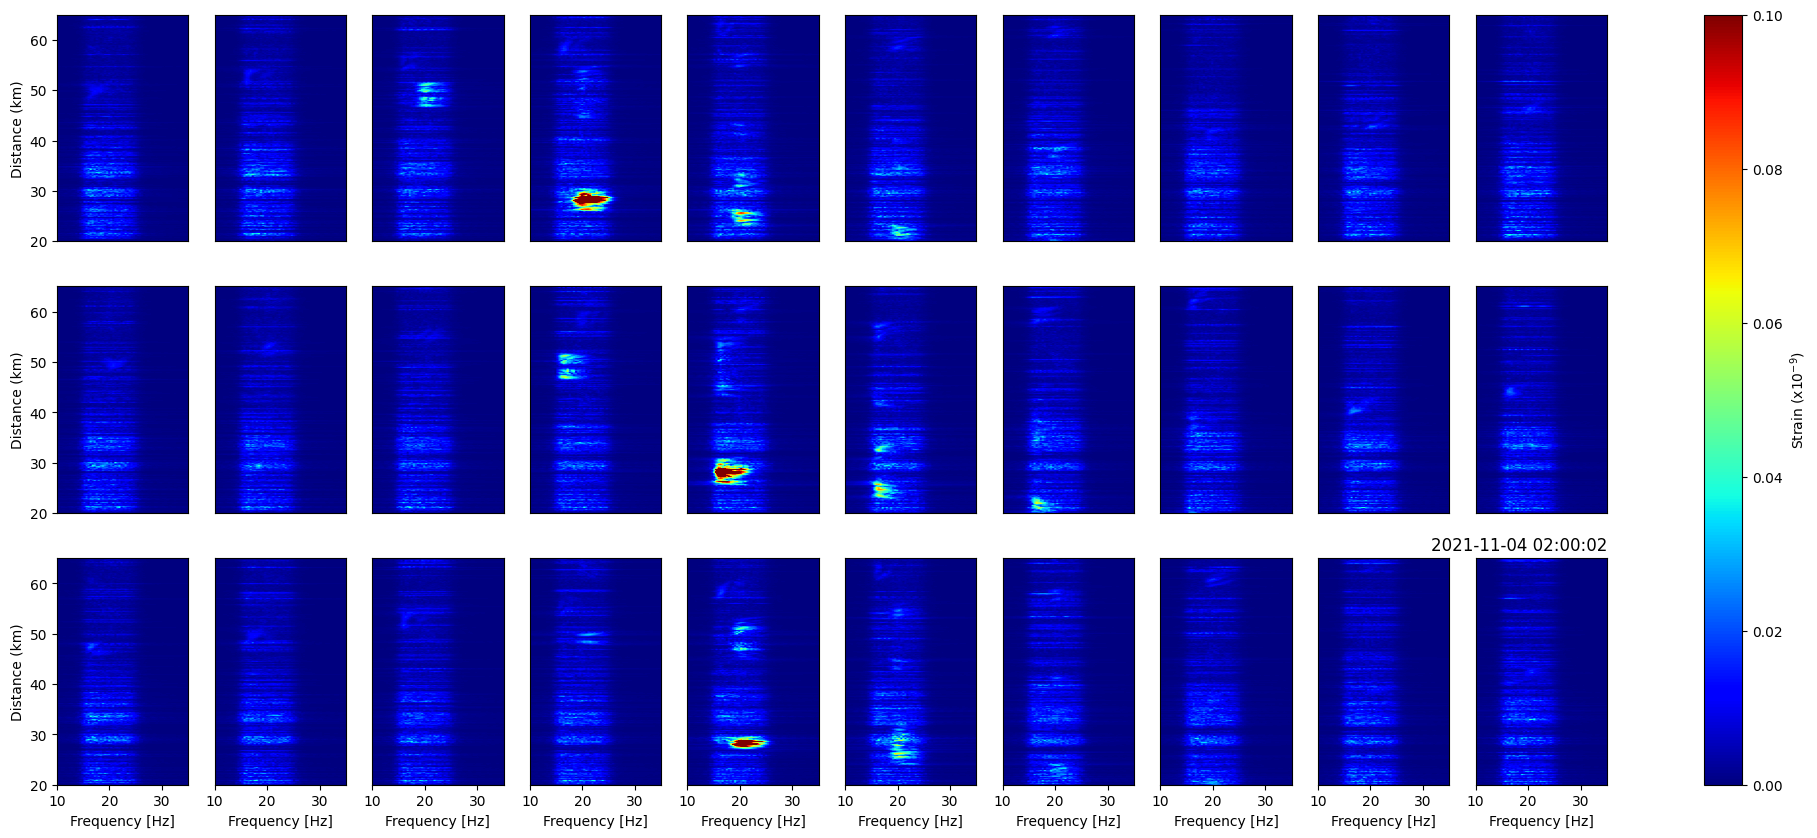

In [13]:
# Spatio-spectral representation (using 2 s segments)
# Frequency x Distance plot

dw.plot.plot_fx(
    trf_fk, dist, fs, title_time_info=fileBeginTimeUTC, win_s=2, nfft=512,  f_min=10, f_max=35, fig_size=(25, 10), 
    v_min = 0, v_max = 0.1)

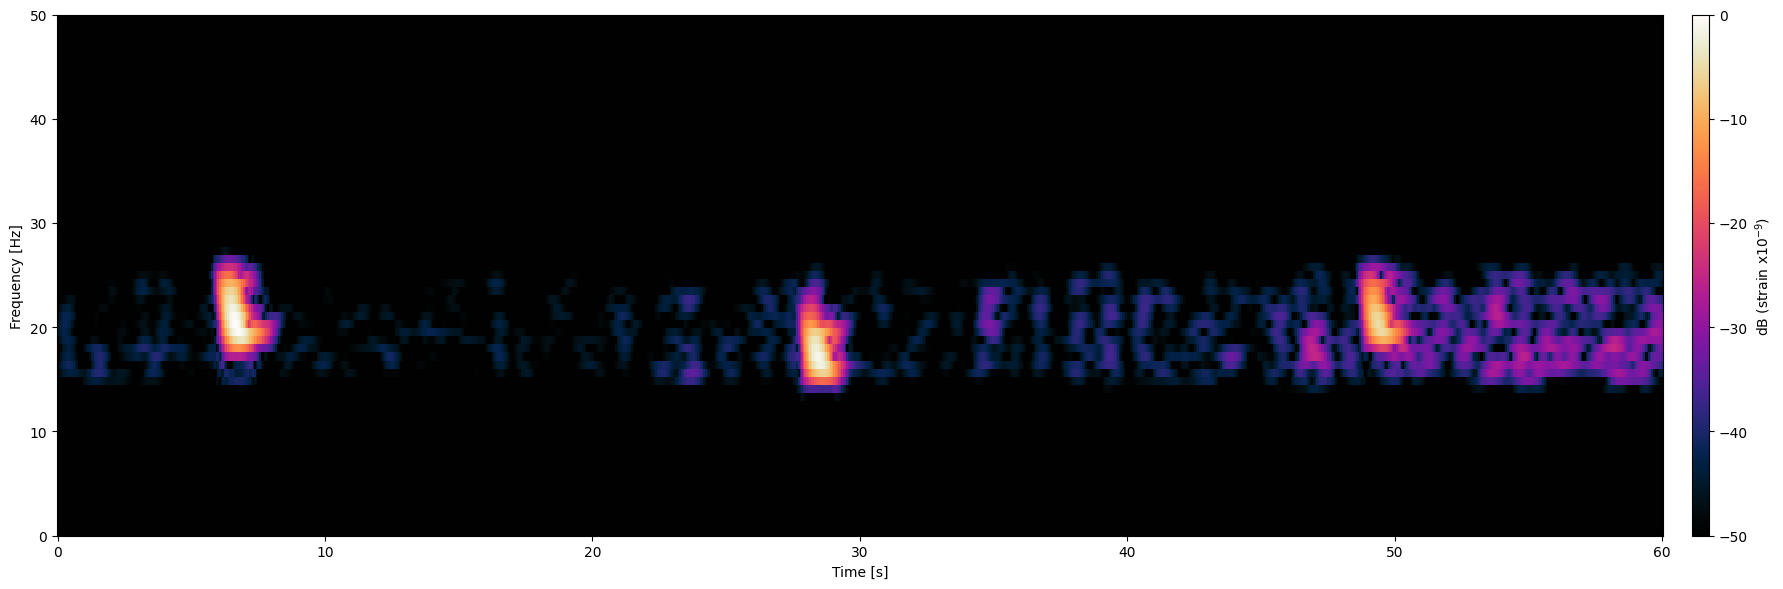

In [14]:
# Select a channel and display audio and its spectrogram

selected_chan = 28000 # (m)
idx = (np.abs(dist - selected_chan)).argmin()

# Spectrogram
p,tt,ff = dw.dsp.get_spectrogram(trf_fk[idx,:], fs, nfft=256, overlap_pct=0.95)
dw.plot.plot_spectrogram(p, tt,ff, f_min = 0, f_max = 50, v_min=-50)

# Audio
display(Audio(data=trf_fk[idx,:], rate=fs*5))